### 

### SPAM EMAIL DETECTION USING ML MODELS 
## Devender Reddy Peddi & Abhiram Ayyannagari

### IMPORTING LIBRARIES AND LOADING DATASET

In [1]:
#  IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

from imblearn.over_sampling import RandomOverSampler, SMOTE


plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')


In [2]:
#  LOAD AND INSPECT DATASET

# Load the dataset
df = pd.read_csv("spam mail.csv")

print(" Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

 Dataset loaded successfully!
Shape of dataset: (5572, 2)

Columns: ['Category', 'Masseges']

First 5 rows:


,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values:
Category    0
Masseges    0
dtype: int64


In [3]:
#  RENAME COLUMNS & BASIC CLEANING
df = df.rename(columns={
    "Category": "label",
    "Masseges": "message"
})

print("\nUnique labels:", df['label'].unique())
print("Label distribution before cleaning:")
print(df['label'].value_counts())

df = df.drop_duplicates().reset_index(drop=True)

print(f"\nShape after removing duplicates: {df.shape}")
print(" Data cleaning completed!")


Unique labels: ['ham' 'spam']
Label distribution before cleaning:
ham     4825
spam     747
Name: label, dtype: int64

Shape after removing duplicates: (5169, 2)
 Data cleaning completed!


### EXPLORATARY DATA ANALYSIS

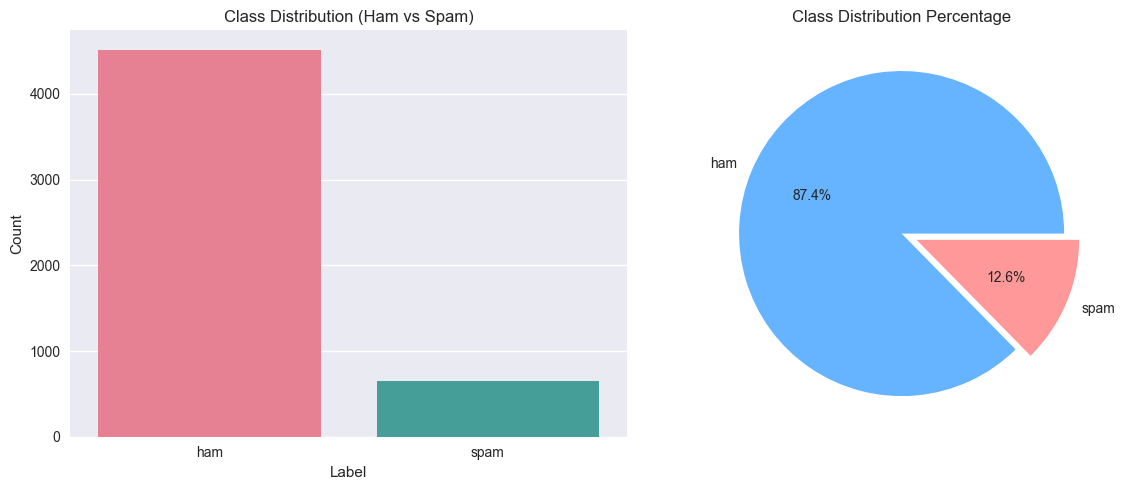

Class Distribution:
ham     4516
spam     653
Name: label, dtype: int64

Percentage:
ham     87.366996
spam    12.633004
Name: label, dtype: float64


In [4]:

# EXPLORATORY DATA ANALYSIS (EDA)
#  Class Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='label', palette='husl')
plt.title('Class Distribution (Ham vs Spam)')
plt.xlabel('Label')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], explode=[0, 0.1])
plt.title('Class Distribution Percentage')
plt.ylabel('')

plt.tight_layout()
plt.show()

print("Class Distribution:")
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

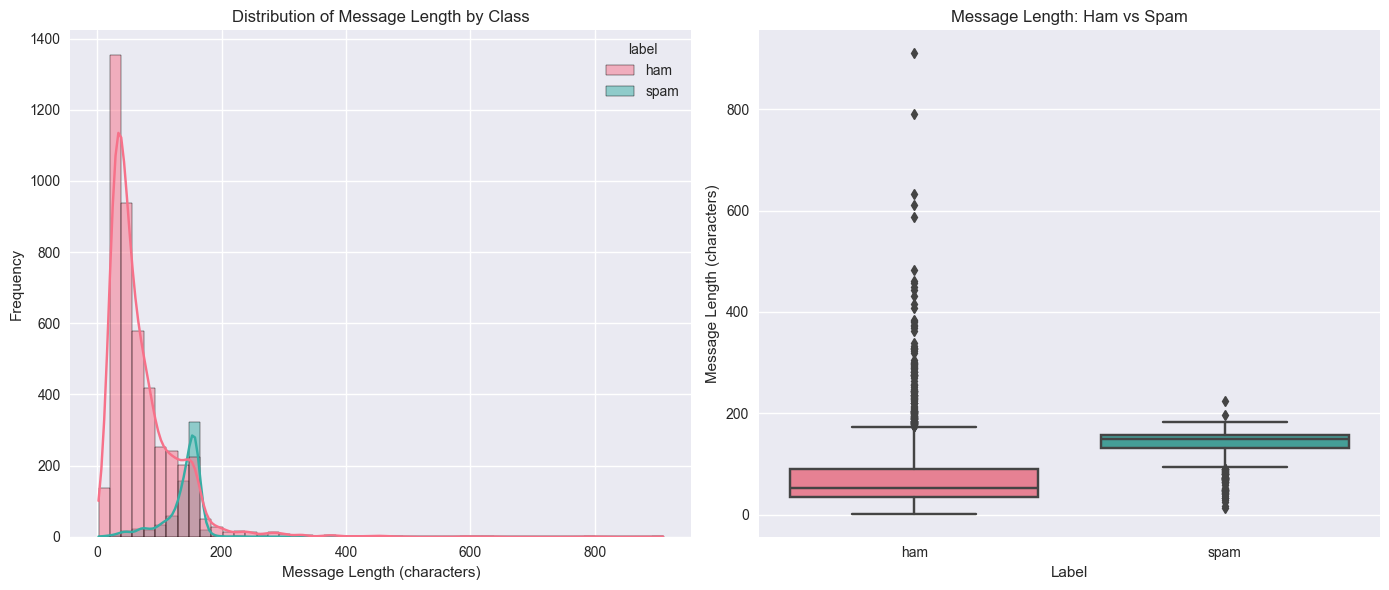


Message Length Statistics:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


In [5]:
#  Message Length Analysis
df['message_length'] = df['message'].astype(str).apply(len)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='husl')
plt.title('Distribution of Message Length by Class')
plt.xlabel('Message Length (characters)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='label', y='message_length', palette='husl')
plt.title('Message Length: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Message Length (characters)')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nMessage Length Statistics:")
print(df.groupby('label')['message_length'].describe())

### LABEL ENCODING AND TEST-TRAIN SPLIT

In [6]:
#  LABEL ENCODING

# Convert 'ham' = 0 and 'spam' = 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(" Label Encoding Completed")
print("\nLabel Distribution after encoding:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

 Label Encoding Completed

Label Distribution after encoding:
0    4516
1     653
Name: label, dtype: int64
0    87.366996
1    12.633004
Name: label, dtype: float64


In [7]:
#  TRAIN-TEST SPLIT 

from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

print(f" Train set size: {len(X_train)} samples")
print(f" Test set size : {len(X_test)} samples")

print("\nClass distribution in Training set (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in Test set (%):")
print(y_test.value_counts(normalize=True) * 100)

 Train set size: 4135 samples
 Test set size : 1034 samples

Class distribution in Training set (%):
0    87.376058
1    12.623942
Name: label, dtype: float64

Class distribution in Test set (%):
0    87.330754
1    12.669246
Name: label, dtype: float64


### TF-IDF VECTORIZATION

In [8]:
# TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,      
    ngram_range=(1, 2),      
    min_df=2,                
    max_df=0.8               
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(" TF-IDF Vectorization completed!")
print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape : {X_test_tfidf.shape}")

 TF-IDF Vectorization completed!
Train TF-IDF shape: (4135, 5000)
Test TF-IDF shape : (1034, 5000)


In [9]:
# BASELINE MODELS 


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

results = {}


# LOGISTIC REGRESSION

In [10]:
# Logistic Regression 
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

results['Logistic Regression (Baseline)'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'report': classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']),
    'confusion': confusion_matrix(y_test, y_pred_lr)
}

print(" Logistic Regression Baseline Done")
print("Accuracy:", round(results['Logistic Regression (Baseline)']['accuracy'], 4))
print(results['Logistic Regression (Baseline)']['report'])

 Logistic Regression Baseline Done
Accuracy: 0.9574
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.98      0.68      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.84      0.89      1034
weighted avg       0.96      0.96      0.95      1034



### SUPPORT VECTOR MACHINE

In [11]:
#  SVM 
svm_model = LinearSVC(random_state=42, max_iter=1000)

svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

results['SVM (Baseline)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'report': classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']),
    'confusion': confusion_matrix(y_test, y_pred_svm)
}

print(" SVM Baseline Done")
print("Accuracy:", round(results['SVM (Baseline)']['accuracy'], 4))
print(results['SVM (Baseline)']['report'])

 SVM Baseline Done
Accuracy: 0.9787
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.85      0.91       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



### VISUAL EVALUATION - BASELINE MODELS

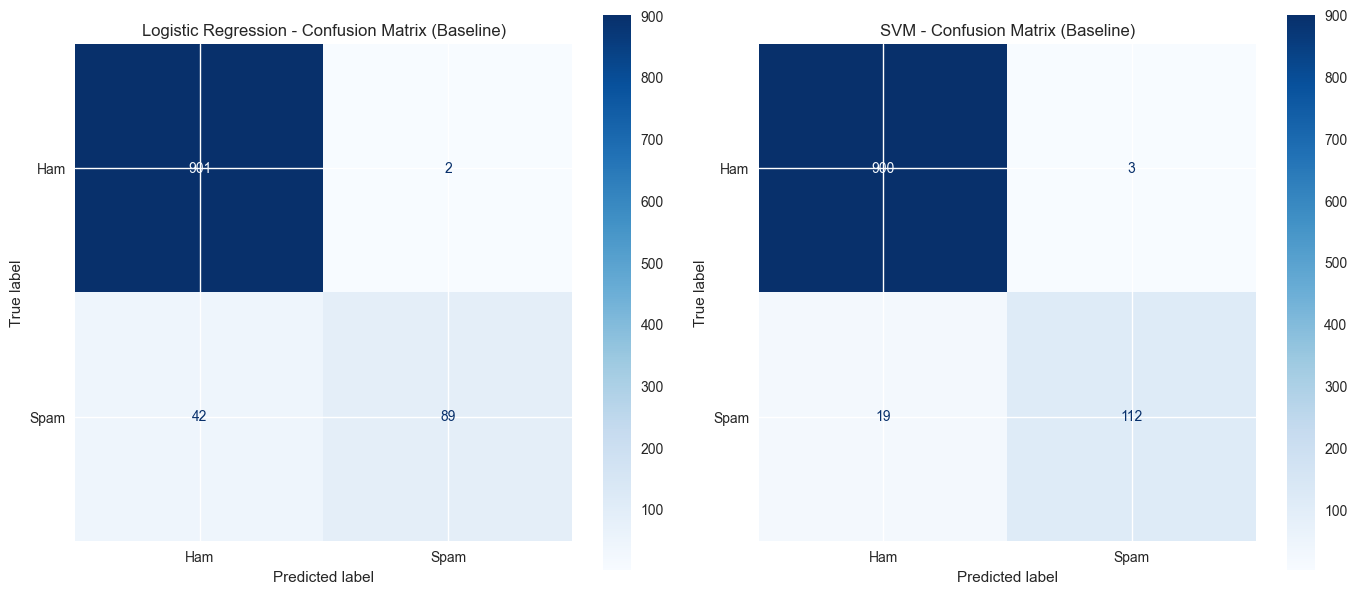

In [12]:
#  VISUAL EVALUATION - BASELINE MODELS

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr_model, X_test_tfidf, y_test, 
                                      display_labels=['Ham', 'Spam'], 
                                      cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix (Baseline)')

# SVM Confusion Matrix
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_tfidf, y_test, 
                                      display_labels=['Ham', 'Spam'], 
                                      cmap='Blues', ax=axes[1])
axes[1].set_title('SVM - Confusion Matrix (Baseline)')

plt.tight_layout()
plt.show()

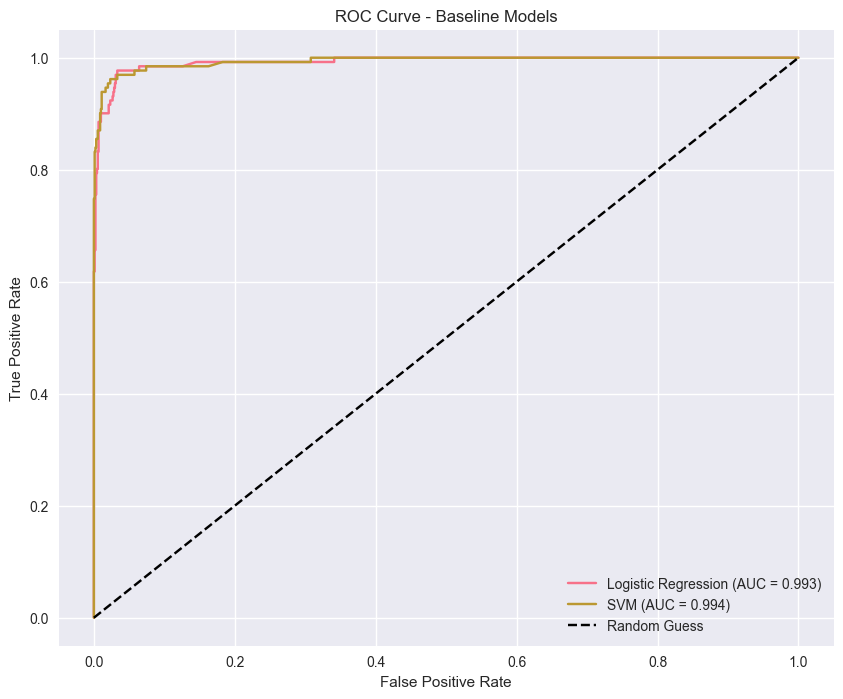

Logistic Regression AUC: 0.9927
SVM AUC: 0.9937


In [13]:
#  ROC-AUC Curves 
plt.figure(figsize=(10, 8))

# Logistic Regression ROC
y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# SVM ROC 
y_score_svm = svm_model.decision_function(X_test_tfidf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Logistic Regression AUC: {roc_auc_lr:.4f}")
print(f"SVM AUC: {roc_auc_svm:.4f}")

In [14]:

from imblearn.over_sampling import RandomOverSampler, SMOTE
import pandas as pd

comparison_results = {}


In [15]:
# Helper function to evaluate model
def evaluate_model(model, X_test_vec, y_test, model_name, technique):
    y_pred = model.predict(X_test_vec)
    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_vec)[:, 1]
    else:
        y_prob = model.decision_function(X_test_vec)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    key = f"{model_name} - {technique}"
    comparison_results[key] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    }
    
    print(f"\n {key}")
    print(f"Accuracy: {acc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {roc:.4f}")
    return y_pred

### TRAIN MODELS WITH DIFFERENT IMBALANCE TECHNIQUES

In [16]:

# STEP 12: TRAIN MODELS WITH DIFFERENT TECHNIQUES

print("Training models with different imbalance handling techniques\n")

# 1. Baseline (already trained earlier)
evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression", "Baseline")
evaluate_model(svm_model, X_test_tfidf, y_test, "SVM", "Baseline")

# 2. Class Weights
print("\n Using Class Weights")
lr_cw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_cw.fit(X_train_tfidf, y_train)
evaluate_model(lr_cw, X_test_tfidf, y_test, "Logistic Regression", "Class Weights")

svm_cw = LinearSVC(class_weight='balanced', random_state=42, max_iter=1000)
svm_cw.fit(X_train_tfidf, y_train)
evaluate_model(svm_cw, X_test_tfidf, y_test, "SVM", "Class Weights")

# 3. Random Oversampling
print("\nUsing Random Oversampling ")
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_tfidf, y_train)

lr_ros = LogisticRegression(max_iter=1000, random_state=42)
lr_ros.fit(X_train_ros, y_train_ros)
evaluate_model(lr_ros, X_test_tfidf, y_test, "Logistic Regression", "Random Oversampling")

svm_ros = LinearSVC(random_state=42, max_iter=1000)
svm_ros.fit(X_train_ros, y_train_ros)
evaluate_model(svm_ros, X_test_tfidf, y_test, "SVM", "Random Oversampling")

# 4. SMOTE
print("\n Using SMOTE ")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
evaluate_model(lr_smote, X_test_tfidf, y_test, "Logistic Regression", "SMOTE")

svm_smote = LinearSVC(random_state=42, max_iter=1000)
svm_smote.fit(X_train_smote, y_train_smote)
evaluate_model(svm_smote, X_test_tfidf, y_test, "SVM", "SMOTE")

print("\n All models trained and evaluated")

Training models with different imbalance handling techniques


 Logistic Regression - Baseline
Accuracy: 0.9574 | Recall: 0.6794 | F1: 0.8018 | AUC: 0.9927

 SVM - Baseline
Accuracy: 0.9787 | Recall: 0.8550 | F1: 0.9106 | AUC: 0.9937

 Using Class Weights

 Logistic Regression - Class Weights
Accuracy: 0.9778 | Recall: 0.8855 | F1: 0.9098 | AUC: 0.9921

 SVM - Class Weights
Accuracy: 0.9787 | Recall: 0.8779 | F1: 0.9127 | AUC: 0.9927

Using Random Oversampling 

 Logistic Regression - Random Oversampling
Accuracy: 0.9778 | Recall: 0.8855 | F1: 0.9098 | AUC: 0.9925

 SVM - Random Oversampling
Accuracy: 0.9787 | Recall: 0.8702 | F1: 0.9120 | AUC: 0.9923

 Using SMOTE 

 Logistic Regression - SMOTE
Accuracy: 0.9778 | Recall: 0.9008 | F1: 0.9112 | AUC: 0.9919

 SVM - SMOTE
Accuracy: 0.9778 | Recall: 0.9008 | F1: 0.9112 | AUC: 0.9886

 All models trained and evaluated


In [17]:
# RESULTS SUMMARY TABLE
results_df = pd.DataFrame(comparison_results).T
results_df = results_df.sort_values(by=['Recall', 'F1-Score'], ascending=False)

print(" COMPARATIVE RESULTS - Spam Detection")
display(results_df.round(4))

 COMPARATIVE RESULTS - Spam Detection


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression - SMOTE,0.9778,0.9219,0.9008,0.9112,0.9919
SVM - SMOTE,0.9778,0.9219,0.9008,0.9112,0.9886
Logistic Regression - Class Weights,0.9778,0.9355,0.8855,0.9098,0.9921
Logistic Regression - Random Oversampling,0.9778,0.9355,0.8855,0.9098,0.9925
SVM - Class Weights,0.9787,0.9504,0.8779,0.9127,0.9927
SVM - Random Oversampling,0.9787,0.9580,0.8702,0.9120,0.9923
SVM - Baseline,0.9787,0.9739,0.8550,0.9106,0.9937
Logistic Regression - Baseline,0.9574,0.9780,0.6794,0.8018,0.9927


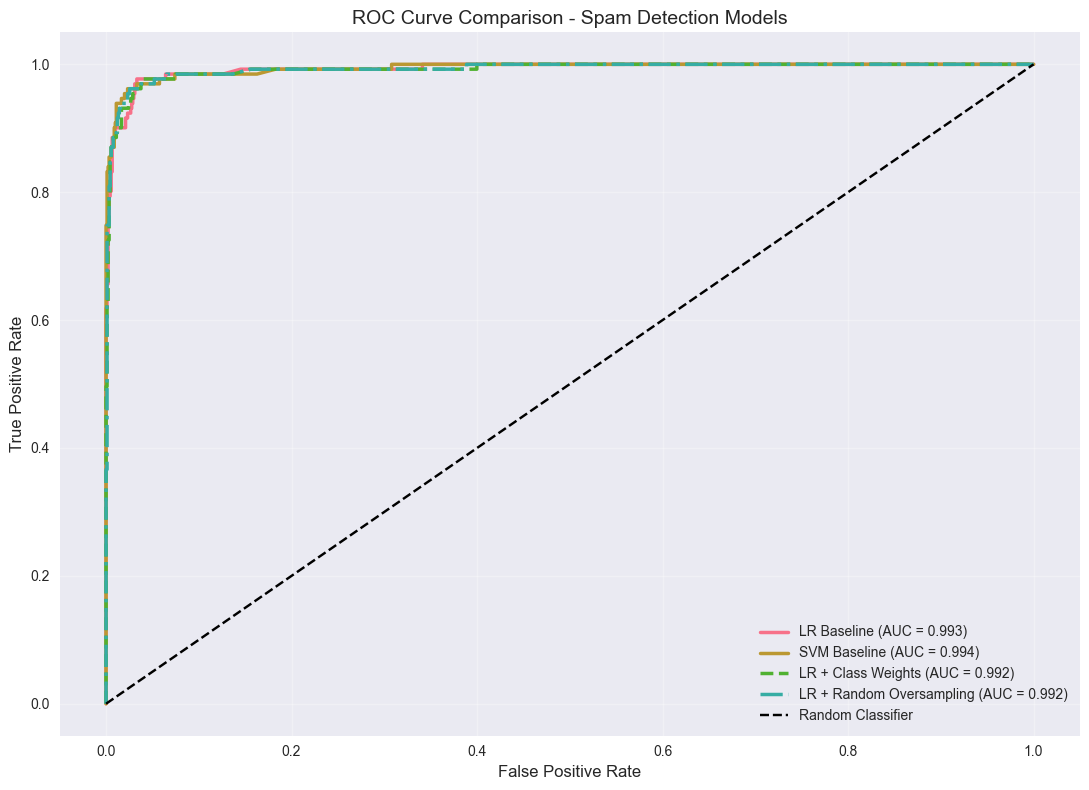

In [18]:
# CLEANER ROC CURVE COMPARISON

plt.figure(figsize=(11, 8))

# Plot only the best / most representative lines
plt.plot(fpr_lr, tpr_lr, linewidth=2.5, label=f'LR Baseline (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_svm, tpr_svm, linewidth=2.5, label=f'SVM Baseline (AUC = {roc_auc_svm:.3f})')

# Best performing imbalance handling models
y_prob_cw = lr_cw.predict_proba(X_test_tfidf)[:, 1]
fpr_cw, tpr_cw, _ = roc_curve(y_test, y_prob_cw)
plt.plot(fpr_cw, tpr_cw, '--', linewidth=2.5, label=f'LR + Class Weights (AUC = {auc(fpr_cw, tpr_cw):.3f})')

y_prob_ros = lr_ros.predict_proba(X_test_tfidf)[:, 1]
fpr_ros, tpr_ros, _ = roc_curve(y_test, y_prob_ros)
plt.plot(fpr_ros, tpr_ros, '-.', linewidth=2.5, label=f'LR + Random Oversampling (AUC = {auc(fpr_ros, tpr_ros):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Spam Detection Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### CONFUSION MATRICES

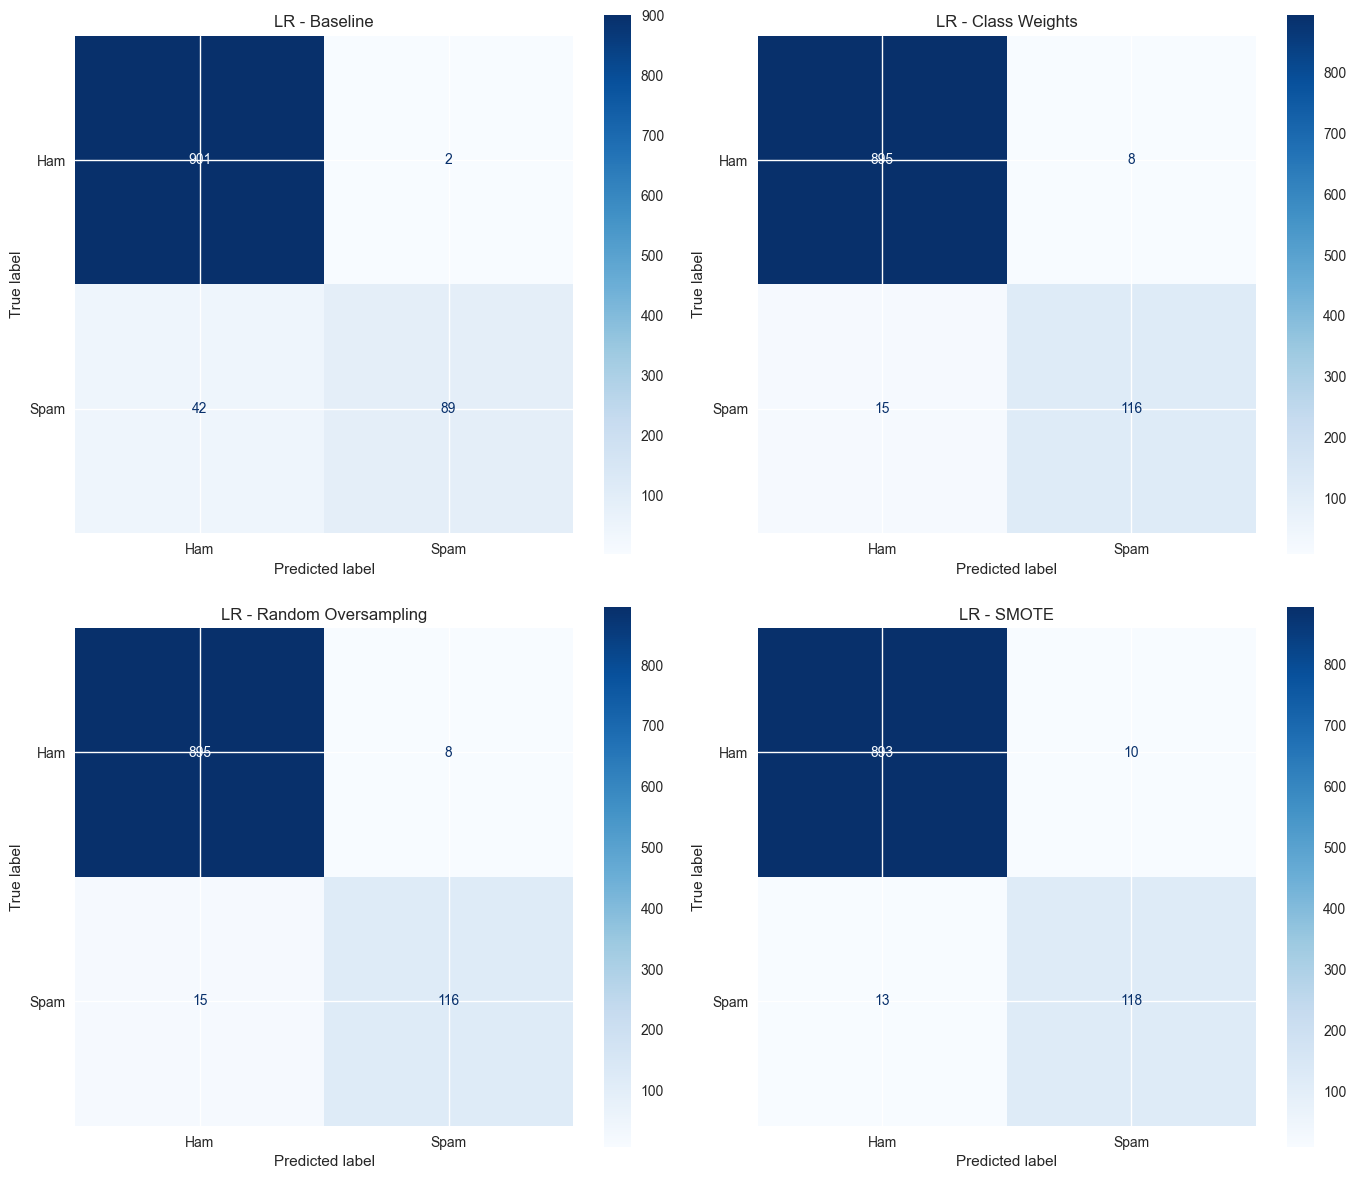

In [19]:

#  CONFUSION MATRICES - BEST PERFORMING MODELS

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

best_models = [
    (lr_model, "LR - Baseline"),
    (lr_cw, "LR - Class Weights"),
    (lr_ros, "LR - Random Oversampling"),
    (lr_smote, "LR - SMOTE")
]

for i, (model, title) in enumerate(best_models):
    row, col = divmod(i, 2)
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_tfidf, y_test,
        display_labels=['Ham', 'Spam'],
        cmap='Blues', ax=axes[row, col]
    )
    axes[row, col].set_title(title)

plt.tight_layout()
plt.show()

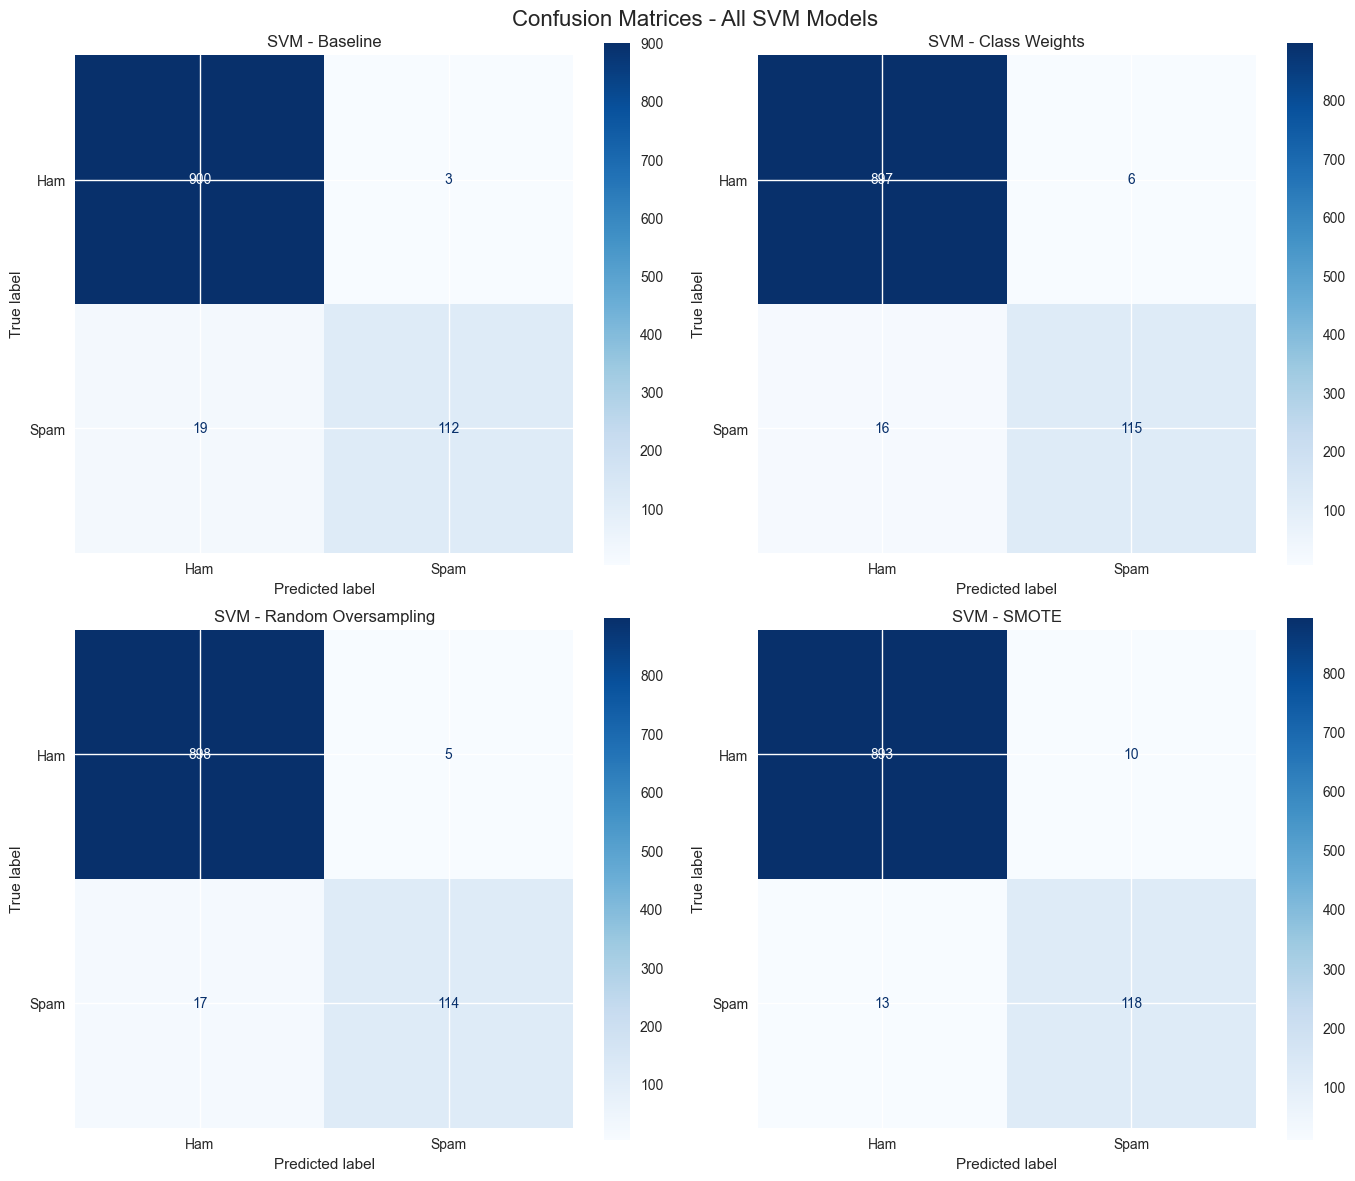

In [20]:

# CONFUSION MATRICES FOR ALL SVM MODELS

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# SVM Models
svm_models = [
    (svm_model, "SVM - Baseline"),
    (svm_cw, "SVM - Class Weights"),
    (svm_ros, "SVM - Random Oversampling"),
    (svm_smote, "SVM - SMOTE")
]

for i, (model, title) in enumerate(svm_models):
    row = i // 2
    col = i % 2
    ConfusionMatrixDisplay.from_estimator(
        model, 
        X_test_tfidf, 
        y_test,
        display_labels=['Ham', 'Spam'],
        cmap='Blues', 
        ax=axes[row, col]
    )
    axes[row, col].set_title(title)

plt.suptitle("Confusion Matrices - All SVM Models", fontsize=16)
plt.tight_layout()
plt.show()

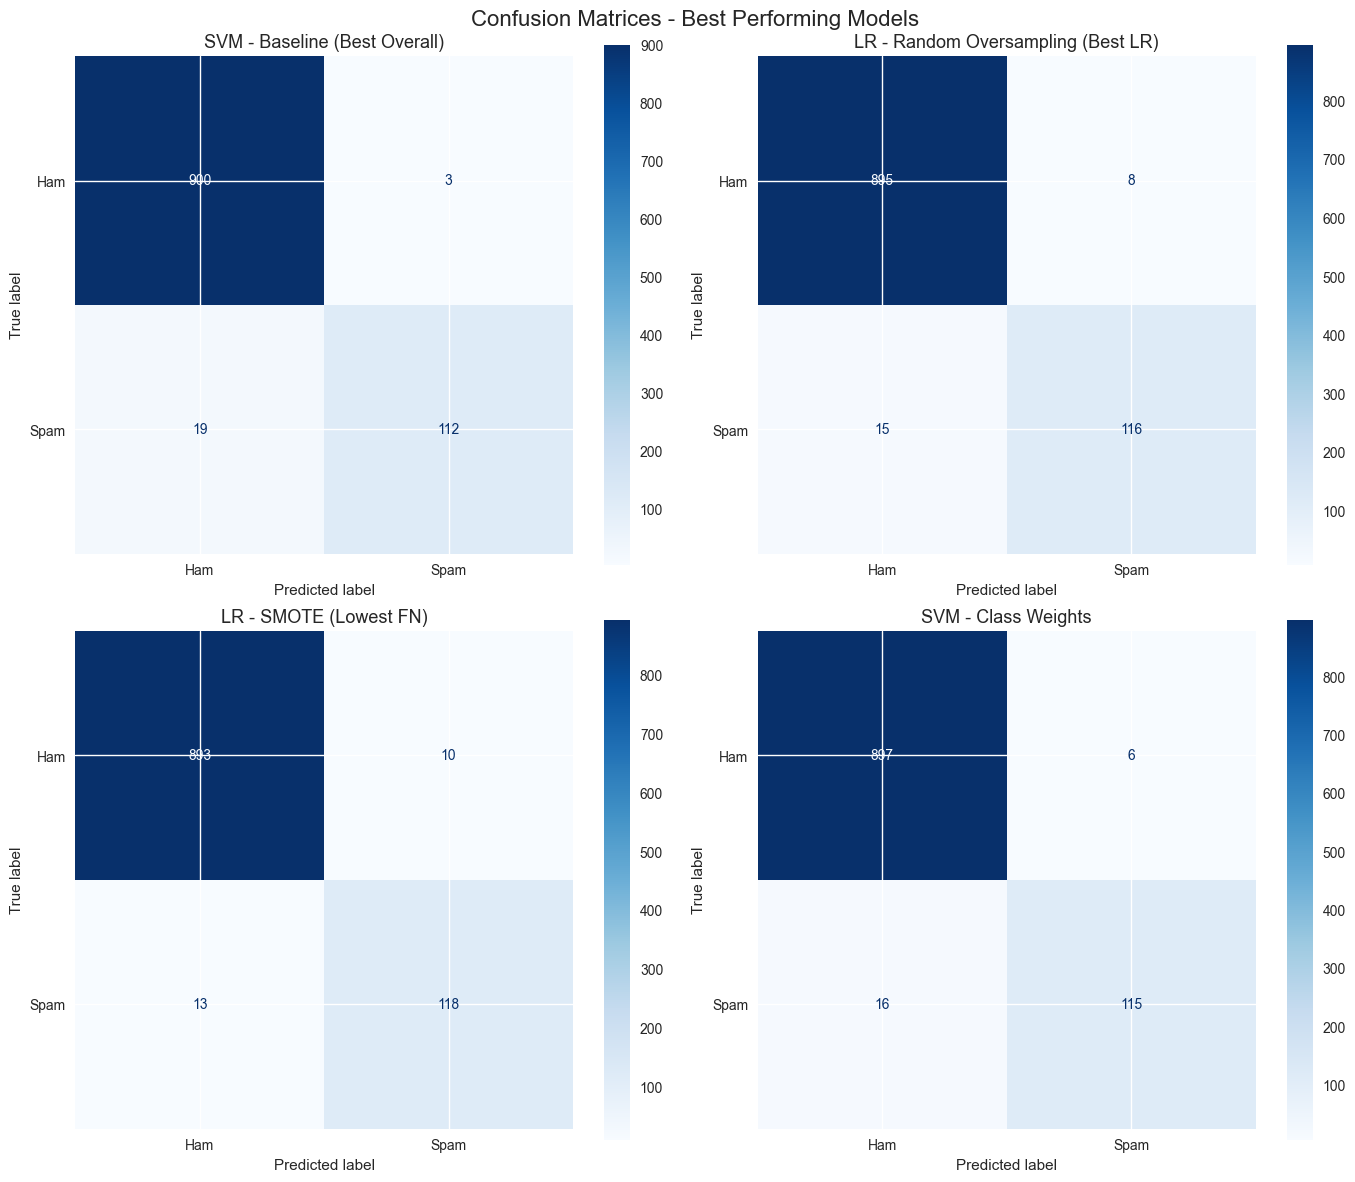

In [21]:

# BEST 4 CONFUSION MATRICES 

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Best 4 Models
best_models = [
    (svm_model, "SVM - Baseline (Best Overall)"),
    (lr_ros, "LR - Random Oversampling (Best LR)"),
    (lr_smote, "LR - SMOTE (Lowest FN)"),
    (svm_cw, "SVM - Class Weights")
]

for i, (model, title) in enumerate(best_models):
    row = i // 2
    col = i % 2
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_tfidf, y_test,
        display_labels=['Ham', 'Spam'],
        cmap='Blues', ax=axes[row, col]
    )
    axes[row, col].set_title(title, fontsize=13)

plt.suptitle("Confusion Matrices - Best Performing Models", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:

print(" FINAL COMPARISON TABLE (Sorted by F1-Score)")
display(results_df.sort_values(by='F1-Score', ascending=False))


print("KEY INSIGHTS FROM THE COMPARATIVE STUDY")
# Find best model
best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_recall = results_df.loc[best_model_name, 'Recall']

print(f"Best Overall Model : {best_model_name}")
print(f"Best F1-Score      : {best_f1:.4f}")
print(f"Spam Recall        : {best_recall:.4f}")



 FINAL COMPARISON TABLE (Sorted by F1-Score)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM - Class Weights,0.9787,0.9504,0.8779,0.9127,0.9927
SVM - Random Oversampling,0.9787,0.9580,0.8702,0.9120,0.9923
Logistic Regression - SMOTE,0.9778,0.9219,0.9008,0.9112,0.9919
SVM - SMOTE,0.9778,0.9219,0.9008,0.9112,0.9886
SVM - Baseline,0.9787,0.9739,0.8550,0.9106,0.9937
Logistic Regression - Class Weights,0.9778,0.9355,0.8855,0.9098,0.9921
Logistic Regression - Random Oversampling,0.9778,0.9355,0.8855,0.9098,0.9925
Logistic Regression - Baseline,0.9574,0.9780,0.6794,0.8018,0.9927


KEY INSIGHTS FROM THE COMPARATIVE STUDY
Best Overall Model : SVM - Class Weights
Best F1-Score      : 0.9127
Spam Recall        : 0.8779


### ERROR ANALYSIS

In [23]:
# ERROR ANALYSIS
# Using the best Logistic Regression model 
best_lr = lr_cw   

y_pred_best = best_lr.predict(X_test_tfidf)

error_analysis = pd.DataFrame({
    'message': X_test,
    'actual': y_test,
    'predicted': y_pred_best
})

# Find misclassified examples
misclassified = error_analysis[error_analysis['actual'] != error_analysis['predicted']].copy()

print(f"Total Misclassified Samples: {len(misclassified)}")
print(f"False Positives (Ham predicted as Spam): {(misclassified['actual'] == 0).sum()}")
print(f"False Negatives (Spam predicted as Ham): {(misclassified['actual'] == 1).sum()}")

# Show some misclassified examples
print("\nSample Misclassified Emails:")
display(misclassified.head(10))

Total Misclassified Samples: 23
False Positives (Ham predicted as Spam): 8
False Negatives (Spam predicted as Ham): 15

Sample Misclassified Emails:


,message,actual,predicted
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0
520,You will recieve your tone within the next 24h...,1,0
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0
75,I am waiting machan. Call me once you free.,0,1
151,Ok... Ur typical reply...,0,1
1422,Hi its LUCY Hubby at meetins all day Fri & I w...,1,0
3947,Missed call alert. These numbers called but le...,1,0
4806,K k:) sms chat with me.,0,1
2302,Babe: U want me dont u baby! Im nasty and have...,1,0
1406,Msg me when rajini comes.,0,1
